In [79]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sqlalchemy import create_engine
import os

In [6]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [7]:
query_min = "SELECT * FROM gold.active_1min"
query_hr = "SELECT * FROM gold.active_1hr"
query_day = "SELECT * FROM gold.active_daily"

In [10]:
df_min = pd.read_sql(query_min,engine)
df_hr = pd.read_sql(query_hr,engine)
df_day = pd.read_sql(query_day,engine)

In [35]:
df_min.info()
df_hr.info()
df_day.info()

<class 'pandas.DataFrame'>
RangeIndex: 126729 entries, 0 to 126728
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   contract  126729 non-null  str    
 1   bar_date  126729 non-null  object 
 2   bar_time  126729 non-null  object 
 3   high      126729 non-null  float64
 4   open      126729 non-null  float64
 5   close     126729 non-null  float64
 6   low       126729 non-null  float64
 7   volume    126729 non-null  float64
dtypes: float64(5), object(2), str(1)
memory usage: 7.7+ MB
<class 'pandas.DataFrame'>
RangeIndex: 2347 entries, 0 to 2346
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   contract        2347 non-null   str    
 1   bar_date        2347 non-null   object 
 2   bar_time        2347 non-null   object 
 3   high            2347 non-null   float64
 4   open            2347 non-null   float64
 5   close           2347 non-n

Daily Volume Analysis

In [21]:
print(df_day['total_volume'].describe())
print("Median: ",df_day['total_volume'].median())
print("Std Dev: ",df_day['total_volume'].std())
print("IQR:", df_day['total_volume'].quantile(0.75) - df_day['total_volume'].quantile(0.25))

count       239.000000
mean      80521.853556
std       51682.915289
min        5609.000000
25%       52092.500000
50%       63354.000000
75%       91315.000000
max      455422.000000
Name: total_volume, dtype: float64
Median:  63354.0
Std Dev:  51682.91528894417
IQR: 39222.5


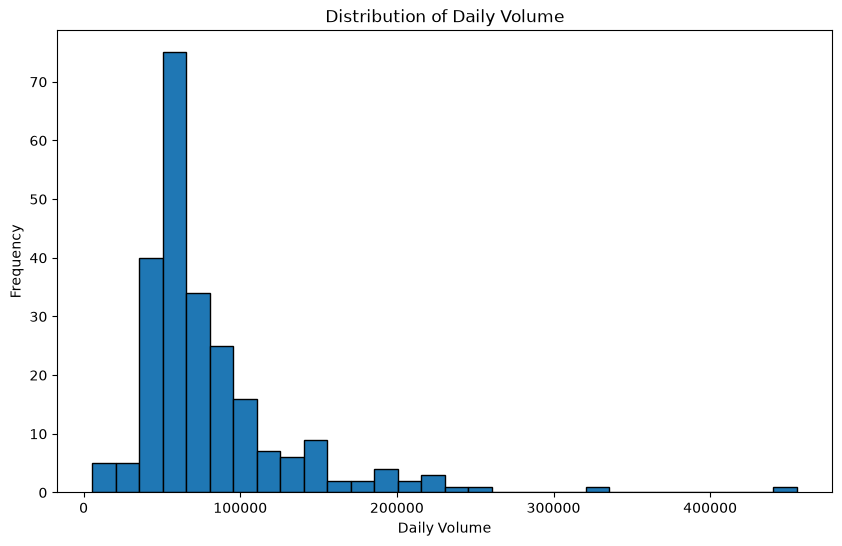

In [16]:
plt.figure(figsize=(10,6))
plt.hist(df_day['total_volume'],bins=30,edgecolor='black')
plt.xlabel('Daily Volume')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Volume')
plt.show()

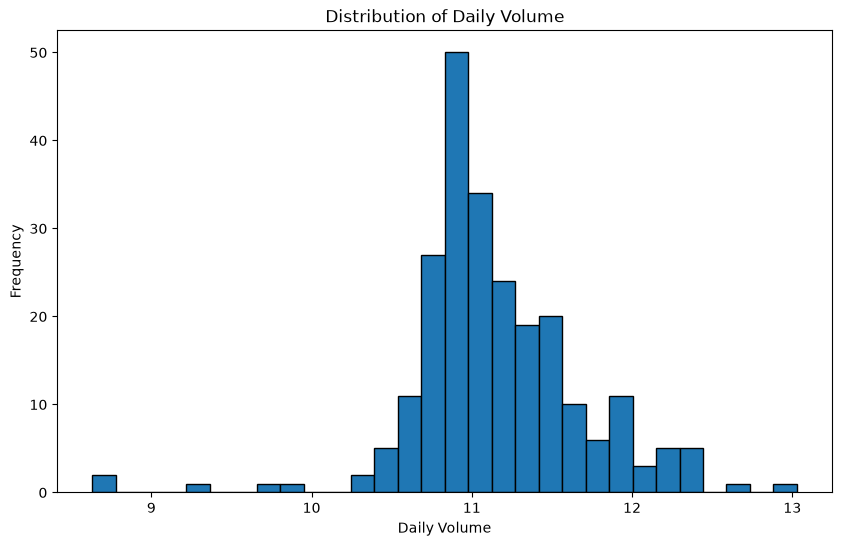

In [28]:
df_day['log_volume']=np.log(df_day['total_volume'])
plt.figure(figsize=(10,6))
plt.hist(df_day['log_volume'],bins=30,edgecolor='black')
plt.xlabel('Daily Volume')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Volume')
plt.show()

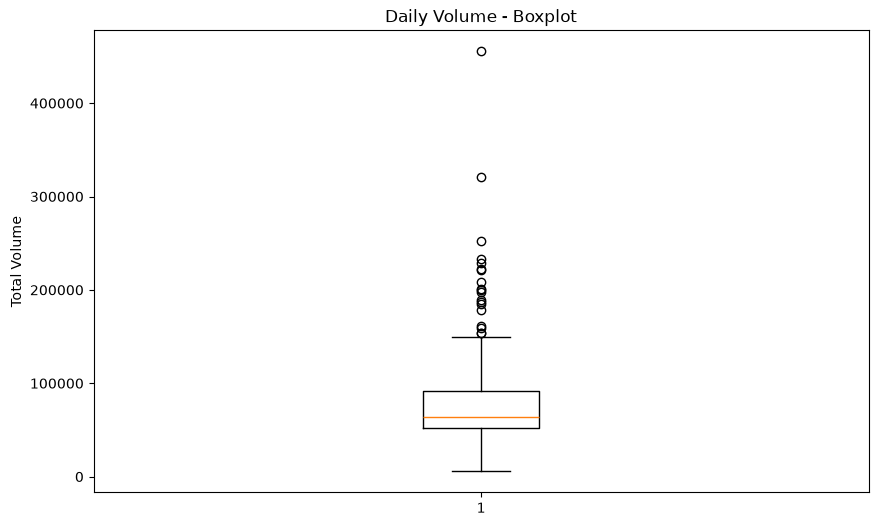

In [31]:
plt.figure(figsize=(10,6))
plt.boxplot(df_day['total_volume'])
plt.ylabel('Total Volume')
plt.title('Daily Volume - Boxplot')
plt.show()

Hour Volume Analysis

In [61]:
hr_agg = df_hr.groupby('bar_time')['total_volume'].agg(['mean','median','std'])
print(hr_agg.sort_values('mean', ascending=False).index)
print(hr_agg.sort_values('std', ascending=True).index)

Index([14:00:00, 13:00:00, 12:00:00, 06:00:00, 11:00:00, 07:00:00, 08:00:00,
       10:00:00, 09:00:00, 15:00:00],
      dtype='object', name='bar_time')
Index([15:00:00, 08:00:00, 10:00:00, 09:00:00, 07:00:00, 11:00:00, 06:00:00,
       14:00:00, 13:00:00, 12:00:00],
      dtype='object', name='bar_time')


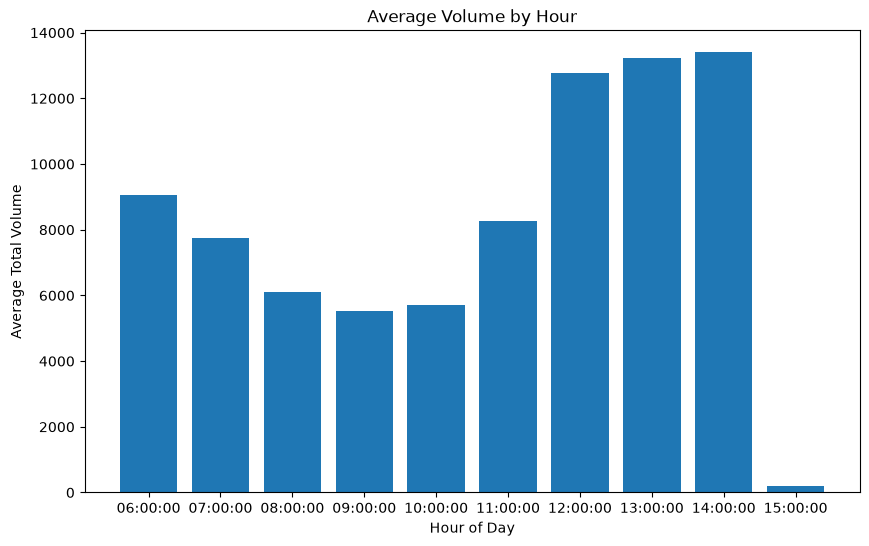

In [40]:

plt.figure(figsize=(10,6))
plt.bar(hr_agg.index.astype(str), hr_agg['mean'])
plt.xlabel('Hour of Day')
plt.ylabel('Average Total Volume')
plt.title('Average Volume by Hour')
plt.show()

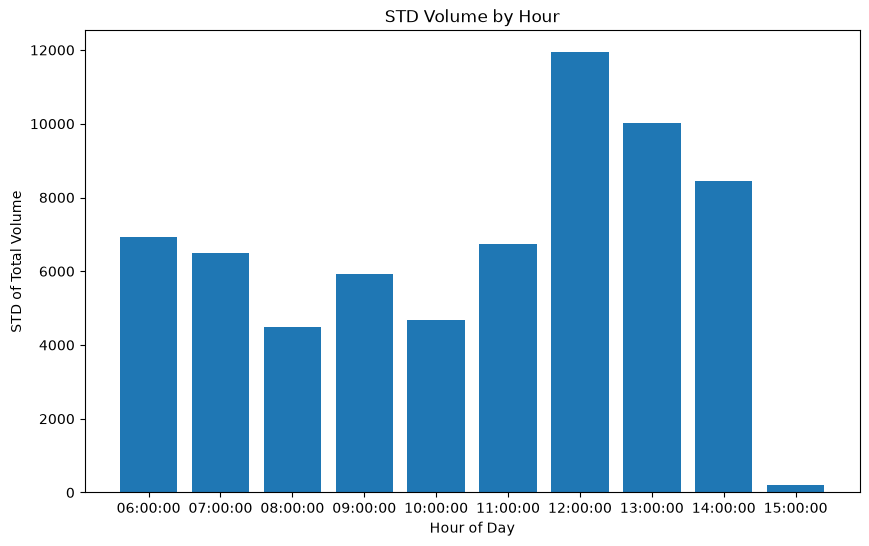

In [55]:
plt.figure(figsize=(10,6))
plt.bar(hr_agg.index.astype(str), hr_agg['std'])
plt.xlabel('Hour of Day')
plt.ylabel('STD of Total Volume')
plt.title('STD Volume by Hour')
plt.show()

Minute Analysis

In [68]:
min_agg = df_min.groupby('bar_time')['volume'].agg(['mean','median','std'])


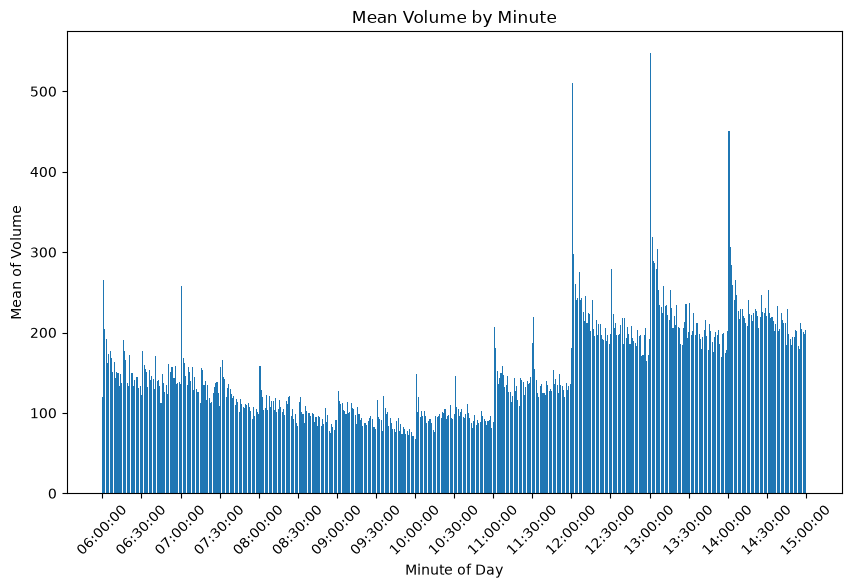

In [87]:
plt.figure(figsize=(10,6))
plt.bar(min_agg.index.astype(str),min_agg['mean'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=20))
plt.xlabel('Minute of Day')
plt.ylabel('Mean of Volume')
plt.title('Mean Volume by Minute')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

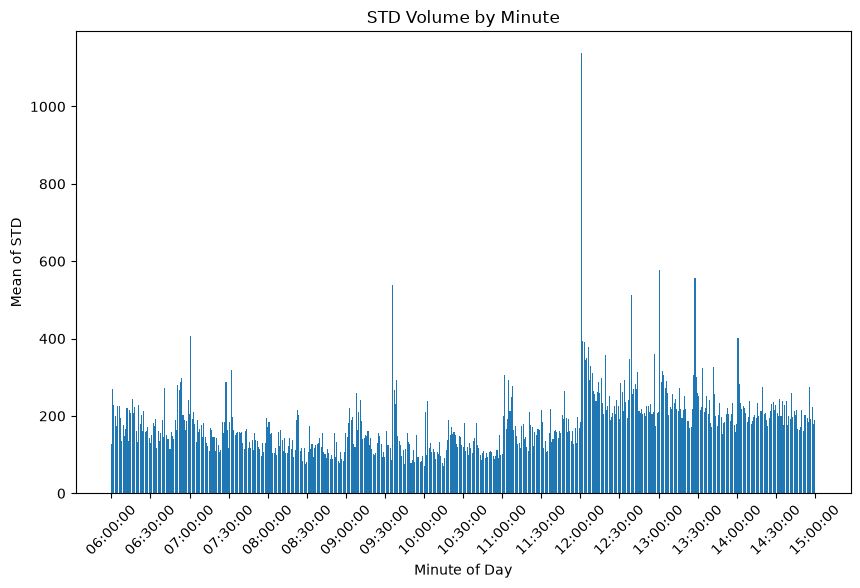

In [88]:
plt.figure(figsize=(10,6))
plt.bar(min_agg.index.astype(str),min_agg['std'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=20))
plt.xlabel('Minute of Day')
plt.ylabel('Mean of STD')
plt.title('STD Volume by Minute')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()